# Diabetes Progression Prediction

## Part 1: Loading the Dataset

### Objective

The objective of this project is to analyse the Diabetes dataset and develop machine learning models to predict disease progression based on patient-related numerical features.

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes

# Load the Diabetes dataset
diabetes = load_diabetes()

# Create a DataFrame
data = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

# Add the target variable
data["target"] = diabetes.target

# Display the first five rows
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Key Observation

The Diabetes dataset was successfully loaded into a Pandas DataFrame. It contains multiple numerical features representing patient-related measurements.

The target variable represents a quantitative measure of disease progression, making this a regression problem.

## Part 2: Dataset Inspection and Data Quality Analysis

### Objective

This section examines the structure and quality of the Diabetes dataset. The analysis includes checking the dataset dimensions, data types, missing values, and summary statistics of the numerical features.

In [2]:
# Display dataset dimensions
print("Dataset Shape:", data.shape)

# Display dataset information
print("\nDataset Information:")
data.info()

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Display summary statistics
print("\nSummary Statistics:")
display(data.describe())

Dataset Shape: (442, 11)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Missing Values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Summary Statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


### Key Observation

The Diabetes dataset contains multiple numerical features and a continuous target variable representing disease progression.

The dataset contains no missing values, making it suitable for regression analysis without requiring additional missing-value treatment. The summary statistics provide an overview of the distributions and ranges of the numerical variables.

## Part 3: Exploratory Data Analysis

### Objective

This section uses visualisation techniques to explore the distributions of selected features in the Diabetes dataset and examine their relationship with disease progression.

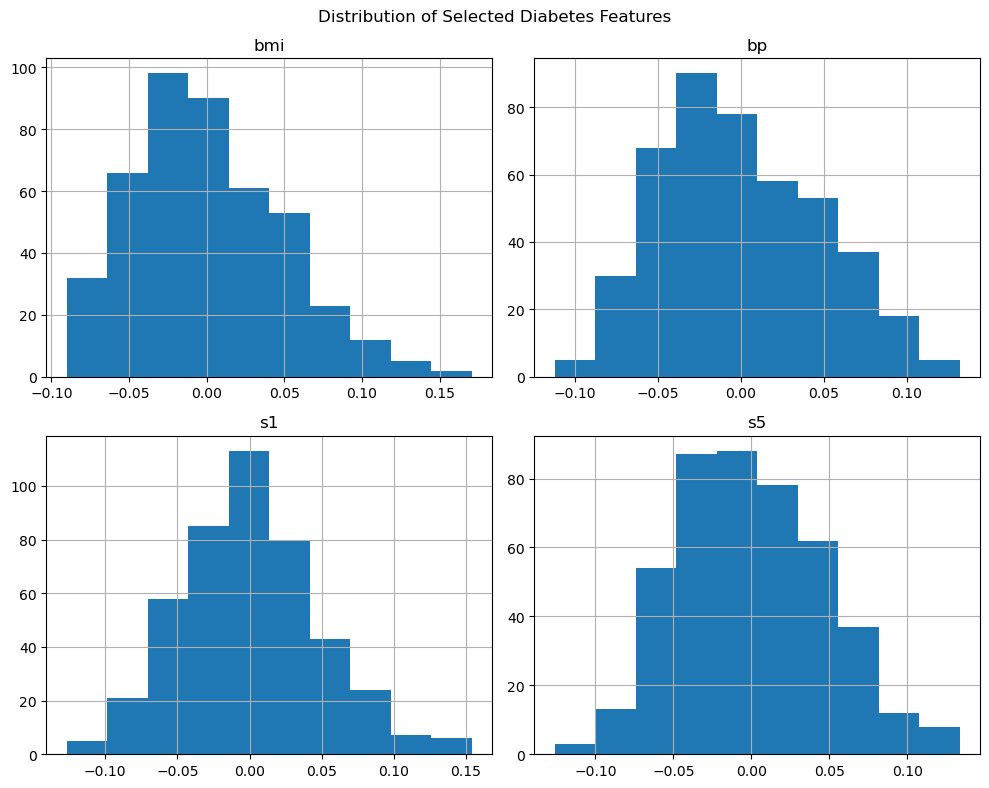

In [4]:
import matplotlib.pyplot as plt

# Plot histograms for selected features
selected_features = ["bmi", "bp", "s1", "s5"]

data[selected_features].hist(figsize=(10, 8))

plt.suptitle("Distribution of Selected Diabetes Features")
plt.tight_layout()
plt.show()

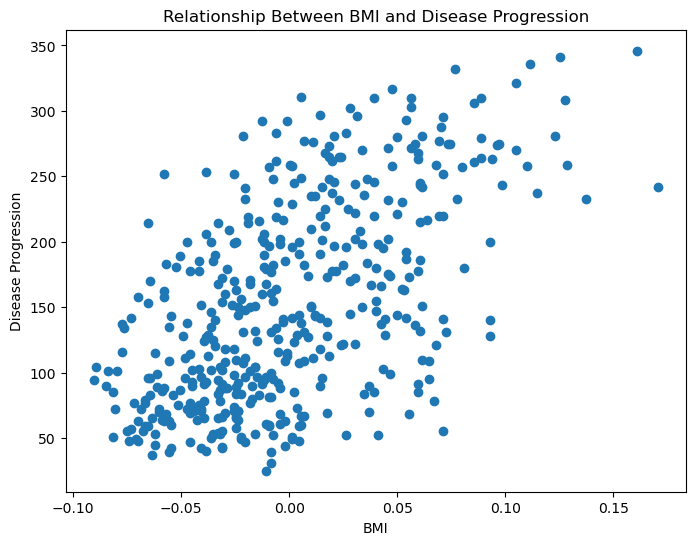

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data["bmi"],
    data["target"]
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Relationship Between BMI and Disease Progression")

plt.show()

### Key Observation

The visualisations provide an overview of the distributions of selected patient-related features.

The scatter plot helps examine the relationship between BMI and disease progression. The observed pattern suggests that BMI may contain useful information for predicting the continuous target variable, although additional features may also contribute to the prediction.

## Part 4: Feature Correlation Analysis

### Objective

This section examines the relationships between the numerical features and the target variable. Correlation analysis helps identify which features have stronger linear relationships with disease progression.

In [6]:
# Calculate the correlation of each feature with the target variable
target_correlation = data.corr()["target"].sort_values(
    ascending=False
)

print("Feature Correlation with Disease Progression:")
print(target_correlation)

Feature Correlation with Disease Progression:
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


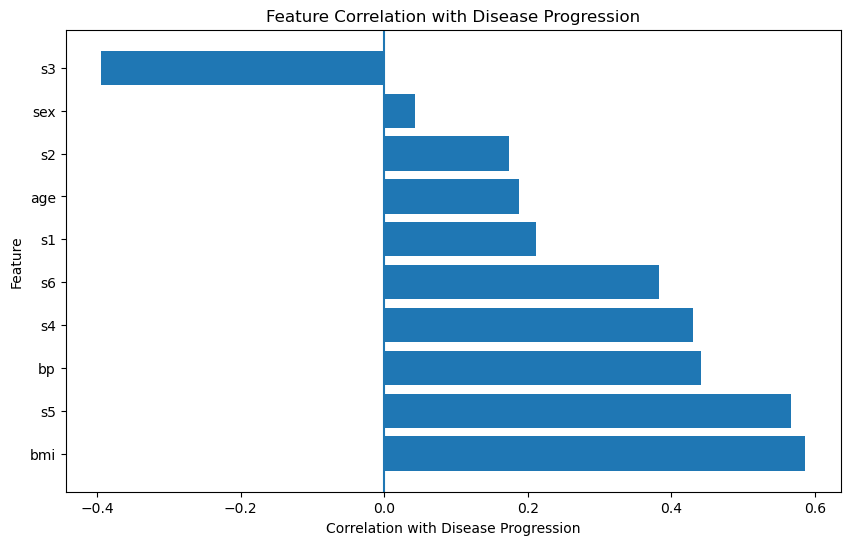

In [7]:
# Remove the target's correlation with itself
feature_correlation = target_correlation.drop("target")

plt.figure(figsize=(10, 6))

plt.barh(
    feature_correlation.index,
    feature_correlation.values
)

plt.xlabel("Correlation with Disease Progression")
plt.ylabel("Feature")
plt.title("Feature Correlation with Disease Progression")

plt.axvline(x=0)

plt.show()

### Key Observation

The correlation analysis shows how strongly each numerical feature is linearly related to disease progression.

Features with larger positive or negative correlation values may contain more useful information for predicting the target variable. However, correlation alone does not determine the overall importance of a feature, as machine learning models can identify more complex relationships between variables.

## Part 5: Data Preparation and Train-Test Split

### Objective

This section prepares the Diabetes dataset for machine learning by separating the input features from the target variable and dividing the data into training and testing sets.

In [8]:
from sklearn.model_selection import train_test_split

# Separate the features and target variable
X = data.drop("target", axis=1)
y = data["target"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (353, 10)
Testing feature shape: (89, 10)

Training target shape: (353,)
Testing target shape: (89,)


### Key Observation

The dataset was successfully divided into training and testing sets.

The training data will be used to develop the regression models, while the testing data will be used to evaluate how well the models predict disease progression on previously unseen observations.

## Part 6: Linear Regression Model

### Objective

This section develops a Linear Regression model to predict disease progression based on the numerical features in the Diabetes dataset.

In [9]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [10]:
# Predict disease progression using the test data
y_pred = model.predict(X_test)

# Compare actual and predicted values
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659
5,84.0,92.172347
6,242.0,258.232389
7,272.0,181.337321
8,94.0,90.224113
9,96.0,108.633759


### Key Observation

The Linear Regression model was successfully trained using the training dataset.

The model can now predict disease progression for previously unseen observations. The next section will evaluate how closely the predicted values match the actual target values.